# Model V2 - Hourly Electricity Price Prediction

This notebook turns the engineered feature table into the first real forecasting model.

Goal: compare a simple time-series baseline with an XGBoost model that uses lag, rolling, calendar, holiday, and weather features.

## Notebook Plan

1. Load the engineered feature table.
2. Check time order, missing values, and target availability.
3. Split by time, not by shuffle.
4. Train a naive baseline for comparison.
5. Train the V2 XGBoost model.
6. Evaluate, inspect errors, and save results.

In [10]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

## 1. Load Data

Use the engineered dataset created by `feature_engineering.ipynb`. This is the main input for V2.

In [2]:
data_path = Path('../data/convertData/finland_electricity_features_v2.csv')
df = pd.read_csv(data_path, parse_dates=['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

print('Shape:', df.shape)
print('Date range:', df['datetime'].min(), '->', df['datetime'].max())
print('Duplicated timestamps:', df['datetime'].duplicated().sum())
df.head(3)

Shape: (26304, 43)
Date range: 2023-01-01 00:00:00 -> 2025-12-31 23:00:00
Duplicated timestamps: 3


,datetime,price,temp,wind_speed,hour,day_of_week,day_of_month,month,week_of_year,quarter,year,season,is_weekend,is_peak_hour,is_night_hour,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,week_of_year_sin,week_of_year_cos,is_holiday,is_non_working,price_lag_1h,price_lag_2h,price_lag_3h,price_lag_6h,price_lag_12h,price_lag_24h,price_lag_48h,price_lag_168h,price_rolling_mean_24h,price_rolling_std_24h,price_rolling_min_24h,price_rolling_max_24h,price_rolling_mean_168h,temp_rolling_mean_24h,HDD,wind_power_proxy,temp_lag_24h,temp_lag_168h
0,2023-01-01 00:00:00,4.84,4.433333,8.516667,0,6,1,1,52,1,2023,1,1,0,1,0.000000,1.000000,-0.781831,0.62349,0.5,0.866025,6.432491e-16,1.0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.566667,617.744588,NaN,NaN
1,2023-01-01 01:00:00,2.01,4.100000,7.716667,1,6,1,1,52,1,2023,1,1,0,1,0.258819,0.965926,-0.781831,0.62349,0.5,0.866025,6.432491e-16,1.0,1,1,4.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.900000,459.503921,NaN,NaN
2,2023-01-01 02:00:00,1.38,3.800000,8.150000,2,6,1,1,52,1,2023,1,1,0,1,0.500000,0.866025,-0.781831,0.62349,0.5,0.866025,6.432491e-16,1.0,1,1,2.01,4.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.200000,541.343375,NaN,NaN


## 2. Target and Feature Check

Keep only columns that are available before prediction time. Remove the target and timestamp from the model input.

In [3]:
target_col = 'price'
time_col = 'datetime'
exclude_cols = {target_col, time_col}

feature_cols = [col for col in df.columns if col not in exclude_cols]
model_df = df[[time_col, target_col] + feature_cols].copy()

print('Number of features:', len(feature_cols))
print('Feature sample:', feature_cols[:15])
print('Missing values (top rows):')
display(model_df.isna().sum().loc[lambda s: s > 0].sort_values(ascending=False).head(20))

Number of features: 41
Feature sample: ['temp', 'wind_speed', 'hour', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'quarter', 'year', 'season', 'is_weekend', 'is_peak_hour', 'is_night_hour', 'hour_sin', 'hour_cos']
Missing values (top rows):


price_lag_168h             168
temp_lag_168h              168
price_rolling_mean_168h    168
price_lag_48h               48
price_rolling_std_24h       24
price_rolling_mean_24h      24
price_lag_24h               24
price_rolling_max_24h       24
temp_rolling_mean_24h       24
price_rolling_min_24h       24
temp_lag_24h                24
price_lag_12h               12
price_lag_6h                 6
price_lag_3h                 3
price_lag_2h                 2
price_lag_1h                 1
dtype: int64

## 3. Time-Based Split

Use chronological splitting so the model only learns from the past and is tested on the future.

In [4]:
model_df = model_df.dropna().reset_index(drop=True)

n_rows = len(model_df)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_val = val_df[feature_cols]
y_val = val_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print('Train:', train_df[time_col].min(), '->', train_df[time_col].max(), X_train.shape)
print('Val  :', val_df[time_col].min(), '->', val_df[time_col].max(), X_val.shape)
print('Test :', test_df[time_col].min(), '->', test_df[time_col].max(), X_test.shape)

Train: 2023-01-08 00:00:00 -> 2025-02-08 06:00:00 (18295, 41)
Val  : 2025-02-08 07:00:00 -> 2025-07-21 15:00:00 (3920, 41)
Test : 2025-07-21 16:00:00 -> 2025-12-31 23:00:00 (3921, 41)


## 4. Naive Baseline

A simple seasonal baseline helps us see whether the model is really learning something useful.

In [5]:
naive_24h = X_test['price_lag_24h']
naive_168h = X_test['price_lag_168h']

def evaluate(y_true, y_pred, name):
    return {
        'model': name,
        'mae': mean_absolute_error(y_true, y_pred),
        'mse': mean_squared_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred),
    }

baseline_results = pd.DataFrame([
    evaluate(y_test, naive_24h, 'Naive_24h'),
    evaluate(y_test, naive_168h, 'Naive_168h'),
])
baseline_results

,model,mae,mse,rmse,r2
0,Naive_24h,35.070666,2916.204214,54.001891,-0.098307
1,Naive_168h,45.359276,4398.778660,66.323289,-0.656678


## 5. Train XGBoost Model

This is the main V2 model. It uses the full engineered feature table instead of raw weather only.

In [6]:
model_v2 = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    tree_method='hist',
)

model_v2.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print('Training finished.')

Training finished.


## 6. Evaluate Model

Compare the engineered-feature model against the naive baseline on the holdout test set.

In [7]:
val_pred = model_v2.predict(X_val)
test_pred = model_v2.predict(X_test)

results = pd.DataFrame([
    evaluate(y_val, val_pred, 'XGB_V2_Val'),
    evaluate(y_test, test_pred, 'XGB_V2_Test'),
])

comparison = pd.concat([baseline_results, results], ignore_index=True)
comparison.sort_values('rmse')

,model,mae,mse,rmse,r2
3,XGB_V2_Test,7.918577,232.939827,15.262366,0.912270
2,XGB_V2_Val,8.969732,328.120486,18.114096,0.881792
0,Naive_24h,35.070666,2916.204214,54.001891,-0.098307
1,Naive_168h,45.359276,4398.778660,66.323289,-0.656678


## 7. Feature Importance and Error Check

Look at the most useful features and inspect the prediction residuals.

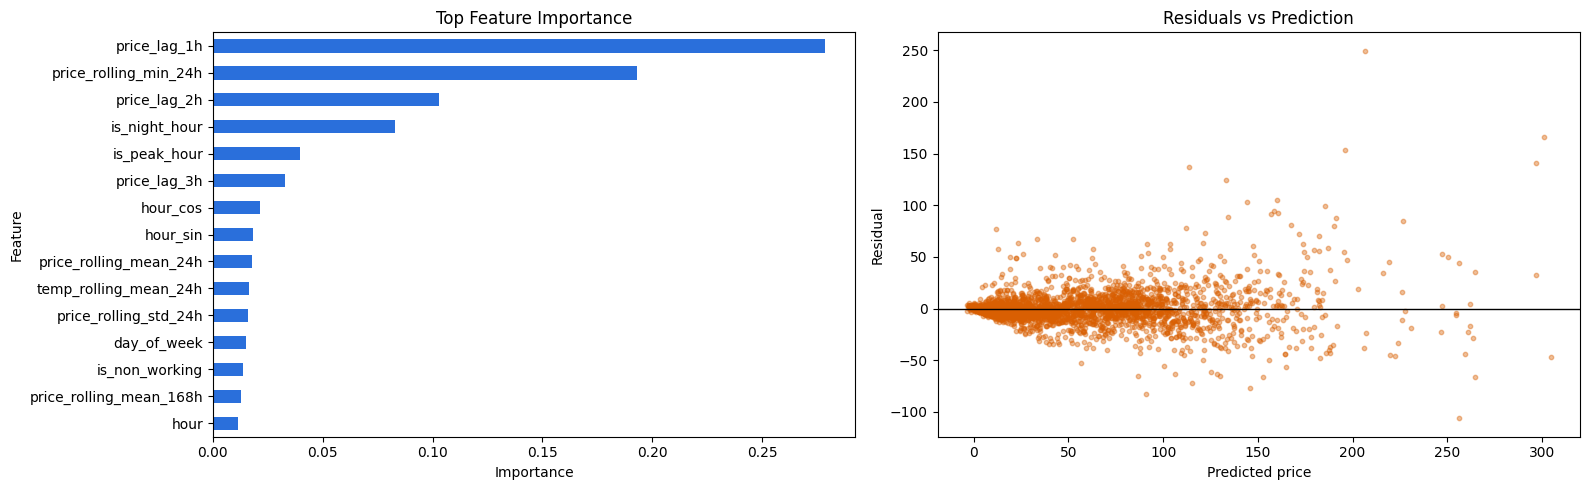

,feature,importance
23,price_lag_1h,0.278449
33,price_rolling_min_24h,0.193071
24,price_lag_2h,0.103012
12,is_night_hour,0.082780
11,is_peak_hour,0.039803
25,price_lag_3h,0.032776
14,hour_cos,0.021431
13,hour_sin,0.018282
31,price_rolling_mean_24h,0.017989
36,temp_rolling_mean_24h,0.016552


In [8]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_v2.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
importance_df.sort_values('importance').plot.barh(x='feature', y='importance', ax=axes[0], legend=False, color='#2a6fdb')
axes[0].set_title('Top Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature')

residuals = y_test - test_pred
axes[1].scatter(test_pred, residuals, s=10, alpha=0.4, color='#d95f02')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Residuals vs Prediction')
axes[1].set_xlabel('Predicted price')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

importance_df

## 8. Save Outputs

Save predictions and the fitted model so the next notebook or script can reuse them.

In [9]:
output_dir = Path('../reports/modelV2')
output_dir.mkdir(parents=True, exist_ok=True)

test_output = test_df[[time_col, target_col]].copy()
test_output['predicted_price'] = test_pred
test_output['residual'] = test_output[target_col] - test_output['predicted_price']
test_output.to_csv(output_dir / 'test_predictions.csv', index=False)
joblib.dump(model_v2, output_dir / 'xgb_model_v2.pkl')
pd.Series(feature_cols, name='feature').to_csv(output_dir / 'feature_columns.csv', index=False)

print('Saved files to:', output_dir.resolve())
print('Test prediction rows:', len(test_output))

Saved files to: E:\Github\nordpool_electricity_price_prediction\reports\modelV2
Test prediction rows: 3921


## 9. Next Steps

If V2 improves over V1, the next upgrade can add cross-validation, SHAP explanations, or a prediction script.